# Report Training Visualizations

Notebook này đọc các artifact hiện có của dự án NIDS-VAE và tạo bảng, biểu đồ phục vụ viết báo cáo Chương 5. Notebook chỉ đọc artifact đã có, không huấn luyện lại mô hình, không fit lại scaler và không tự bịa số liệu.

In [1]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Thiết lập đường dẫn gốc để notebook chạy được cả khi mở từ thư mục notebooks.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "artifacts").exists() else CURRENT_DIR.parent

ARTIFACT_PATHS = {
    "training_history": PROJECT_ROOT / "artifacts/models/training_history.json",
    "training_summary": PROJECT_ROOT / "artifacts/models/training_summary.json",
    "evaluation_metrics": PROJECT_ROOT / "artifacts/threshold/evaluation_metrics.json",
    "confusion_matrix": PROJECT_ROOT / "artifacts/threshold/confusion_matrix.json",
}

TABLE_DIR = PROJECT_ROOT / "reports/tables"
FIGURE_DIR = PROJECT_ROOT / "reports/figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

created_files = []
missing_outputs = {}

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.family": "DejaVu Sans",
})


In [2]:
def warn_vi(message: str) -> None:
    # Cảnh báo rõ ràng bằng tiếng Việt khi thiếu dữ liệu hoặc không đủ thông tin để vẽ/lưu.
    warnings.warn(message, stacklevel=2)
    print(f"[CẢNH BÁO] {message}")


def load_json_if_exists(path: Path, label: str):
    # Đọc JSON nếu tồn tại; nếu thiếu thì bỏ qua để notebook không bị crash.
    if not path.exists():
        warn_vi(f"Không tìm thấy {label}: {path}. Bỏ qua phần liên quan.")
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def nested_get(data, path, default=None):
    # Lấy giá trị trong dict lồng nhau theo danh sách key.
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def first_existing(data: dict, candidates: list[str]):
    # Dò key linh hoạt vì artifact có thể dùng nhiều tên trường khác nhau.
    for key in candidates:
        if isinstance(data, dict) and key in data:
            return data[key]
    return None


def to_number(value):
    # Chuyển giá trị về số thực khi có thể; giữ NaN cho các giá trị thiếu.
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def fmt_value(value, digits: int = 6):
    # Định dạng số cho bảng Markdown/CSV, dùng N/A khi không có dữ liệu thật.
    number = to_number(value)
    if np.isnan(number):
        return "N/A"
    return f"{number:.{digits}f}"


def save_table(df: pd.DataFrame, csv_path: Path, md_path: Path) -> None:
    # Lưu bảng ở cả CSV và Markdown để thuận tiện đưa vào báo cáo.
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    markdown_text = dataframe_to_markdown(df)
    md_path.write_text(markdown_text, encoding="utf-8")
    created_files.extend([csv_path, md_path])


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    # Tự tạo bảng Markdown để không phụ thuộc package tabulate.
    columns = [str(column) for column in df.columns]
    rows = [[str(value) for value in row] for row in df.to_numpy()]
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines) + "\n"


def save_figure(path: Path) -> None:
    # Lưu hình với độ phân giải đủ tốt cho báo cáo.
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    created_files.append(path)


In [3]:
training_history = load_json_if_exists(ARTIFACT_PATHS["training_history"], "training_history.json")
training_summary = load_json_if_exists(ARTIFACT_PATHS["training_summary"], "training_summary.json")
evaluation_metrics = load_json_if_exists(ARTIFACT_PATHS["evaluation_metrics"], "evaluation_metrics.json")
confusion_matrix_data = load_json_if_exists(ARTIFACT_PATHS["confusion_matrix"], "confusion_matrix.json")


In [4]:
HISTORY_KEY_CANDIDATES = {
    "train_loss": ["train_loss", "loss", "total_loss"],
    "train_recon_loss": ["train_recon_loss", "train_recon", "recon_loss", "reconstruction_loss", "train_reconstruction_loss"],
    "train_kl_loss": ["train_kl_loss", "train_kl", "kl_loss", "kld_loss", "train_kld_loss"],
    "val_loss": ["val_loss", "validation_loss", "valid_loss"],
    "val_recon_loss": ["val_recon_loss", "val_recon", "validation_recon_loss", "valid_recon_loss", "val_reconstruction_loss"],
    "val_kl_loss": ["val_kl_loss", "val_kl", "validation_kl_loss", "valid_kl_loss", "val_kld_loss"],
}


def normalize_history(history):
    # Chuẩn hóa training_history thành DataFrame theo epoch, hỗ trợ cả dict list-based và list record-based.
    if history is None:
        return pd.DataFrame()

    if isinstance(history, list):
        rows = []
        for idx, record in enumerate(history, start=1):
            if not isinstance(record, dict):
                continue
            row = {"epoch": int(record.get("epoch", idx))}
            for canonical_key, candidates in HISTORY_KEY_CANDIDATES.items():
                row[canonical_key] = to_number(first_existing(record, candidates))
            rows.append(row)
        return pd.DataFrame(rows)

    if isinstance(history, dict):
        max_len = 0
        extracted = {}
        for canonical_key, candidates in HISTORY_KEY_CANDIDATES.items():
            values = first_existing(history, candidates)
            if isinstance(values, list):
                extracted[canonical_key] = [to_number(value) for value in values]
                max_len = max(max_len, len(values))

        if max_len == 0:
            warn_vi("training_history.json không có chuỗi loss phù hợp để tạo bảng/biểu đồ.")
            return pd.DataFrame()

        rows = []
        for idx in range(max_len):
            row = {"epoch": idx + 1}
            for canonical_key in HISTORY_KEY_CANDIDATES:
                values = extracted.get(canonical_key, [])
                row[canonical_key] = values[idx] if idx < len(values) else np.nan
            rows.append(row)
        return pd.DataFrame(rows)

    warn_vi("training_history.json có định dạng chưa được hỗ trợ.")
    return pd.DataFrame()


history_df = normalize_history(training_history)
history_df.head()


,epoch,train_loss,train_recon_loss,train_kl_loss,val_loss,val_recon_loss,val_kl_loss
0,1,1196.320911,15.641376,35420.384203,0.378644,0.263542,3.453047
1,2,0.602273,0.376816,3.381854,0.393427,0.235934,2.362394
2,3,189.280611,13.150862,1761.297536,0.407739,0.220264,1.874752
3,4,0.550859,0.340583,1.577075,0.442454,0.247373,1.463109
4,5,0.571306,0.358923,1.274300,0.483412,0.283726,1.198116


In [5]:
def get_best_epoch(summary, history: pd.DataFrame):
    # Ưu tiên best_epoch từ summary; nếu thiếu thì chọn epoch có val_loss nhỏ nhất.
    summary_candidates = [
        nested_get(summary, ["results", "best_epoch"]),
        nested_get(summary, ["best_epoch"]),
    ]
    for candidate in summary_candidates:
        if candidate is not None:
            return int(candidate)

    if not history.empty and "val_loss" in history and history["val_loss"].notna().any():
        return int(history.loc[history["val_loss"].idxmin(), "epoch"])
    return None


def get_warmup_epoch(summary):
    # Lấy mốc kết thúc KL warmup từ summary; mặc định theo yêu cầu là 30 nếu có cấu hình warmup.
    warmup = nested_get(summary, ["kl_annealing", "beta_warmup_epochs"])
    if warmup is None:
        warmup = nested_get(summary, ["hyperparameters", "beta_warmup_epochs"])
    return int(warmup) if warmup is not None else 30


def selected_epoch_rows(history: pd.DataFrame, best_epoch: int | None):
    # Chọn các epoch phục vụ Bảng 5.3 và 5.4, chỉ lấy dòng có thật trong history.
    if history.empty:
        return []

    final_epoch = int(history["epoch"].max())
    requested = [
        (1, "Epoch 1"),
        (10, "Epoch 10"),
        (20, "Epoch 20"),
        (30, "Epoch 30"),
    ]
    if best_epoch is not None:
        requested.append((best_epoch, "Best Epoch"))
    requested.append((final_epoch, "Final Epoch"))

    rows = []
    for epoch, note in requested:
        match = history[history["epoch"] == epoch]
        if match.empty:
            warn_vi(f"Không có dữ liệu cho {note} (epoch {epoch}) trong training_history.json.")
            continue
        record = match.iloc[0].to_dict()
        record["note"] = note
        rows.append(record)
    return rows


best_epoch = get_best_epoch(training_summary, history_df)
warmup_epoch = get_warmup_epoch(training_summary)

print(f"Best Epoch: {best_epoch if best_epoch is not None else 'N/A'}")
print(f"Warmup End Epoch: {warmup_epoch if warmup_epoch is not None else 'N/A'}")
print(f"Final Epoch: {int(history_df['epoch'].max()) if not history_df.empty else 'N/A'}")


Best Epoch: 58
Warmup End Epoch: 30
Final Epoch: 68


In [6]:
if history_df.empty:
    missing_outputs["Bảng 5.3"] = "Thiếu training_history.json hoặc không có dữ liệu train loss."
else:
    rows = []
    for record in selected_epoch_rows(history_df, best_epoch):
        rows.append({
            "Epoch": int(record["epoch"]),
            "Train Loss (Tổng)": fmt_value(record.get("train_loss")),
            "Train Reconstruction Loss (MSE)": fmt_value(record.get("train_recon_loss")),
            "Train KL Divergence Loss": fmt_value(record.get("train_kl_loss")),
            "Ghi chú": record["note"],
        })
    table_5_3 = pd.DataFrame(rows)
    save_table(
        table_5_3,
        TABLE_DIR / "table_5_3_train_loss.csv",
        TABLE_DIR / "table_5_3_train_loss.md",
    )
    display(table_5_3)


,Epoch,Train Loss (Tổng),Train Reconstruction Loss (MSE),Train KL Divergence Loss,Ghi chú
0,1,1196.320911,15.641376,35420.384203,Epoch 1
1,10,0.683961,0.478940,0.615062,Epoch 10
2,20,0.759444,0.623403,0.204062,Epoch 20
3,30,0.798421,0.673846,0.124575,Epoch 30
4,58,0.772250,0.662123,0.110128,Best Epoch
5,68,0.765520,0.667154,0.098366,Final Epoch


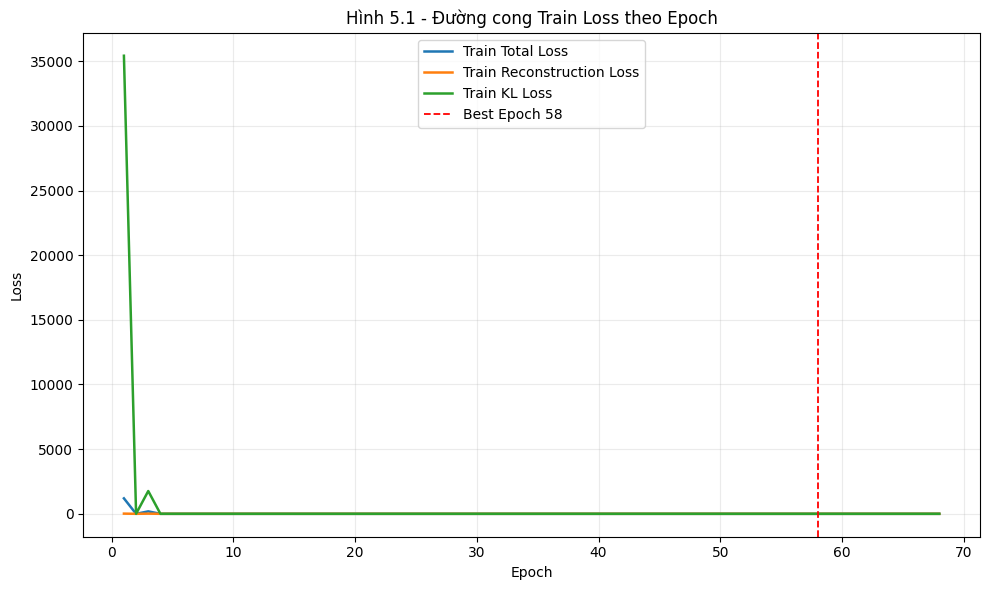

In [7]:
def plot_available_series(df: pd.DataFrame, series_map: dict[str, str]) -> bool:
    # Vẽ các chuỗi loss có dữ liệu thật, bỏ qua chuỗi bị thiếu.
    plotted = False
    for column, label in series_map.items():
        if column in df and df[column].notna().any():
            plt.plot(df["epoch"], df[column], label=label, linewidth=1.8)
            plotted = True
    return plotted


if history_df.empty or not history_df.get("train_loss", pd.Series(dtype=float)).notna().any():
    missing_outputs["Hình 5.1"] = "Thiếu dữ liệu train loss."
    warn_vi("Không đủ dữ liệu để vẽ Hình 5.1 - Đường cong Train Loss.")
else:
    plt.figure()
    plot_available_series(history_df, {
        "train_loss": "Train Total Loss",
        "train_recon_loss": "Train Reconstruction Loss",
        "train_kl_loss": "Train KL Loss",
    })
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", linewidth=1.3, label=f"Best Epoch {best_epoch}")
    plt.title("Hình 5.1 - Đường cong Train Loss theo Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    save_figure(FIGURE_DIR / "figure_5_1_train_loss_curve.png")


In [8]:
if history_df.empty:
    missing_outputs["Bảng 5.4"] = "Thiếu training_history.json hoặc không có dữ liệu validation loss."
else:
    rows = []
    for record in selected_epoch_rows(history_df, best_epoch):
        train_loss = to_number(record.get("train_loss"))
        val_loss = to_number(record.get("val_loss"))
        gap = val_loss - train_loss if not np.isnan(train_loss) and not np.isnan(val_loss) else np.nan
        rows.append({
            "Epoch": int(record["epoch"]),
            "Validation Loss (Tổng)": fmt_value(val_loss),
            "Val Reconstruction Loss": fmt_value(record.get("val_recon_loss")),
            "Generalization Gap": fmt_value(gap),
            "Ghi chú": record["note"],
        })
    table_5_4 = pd.DataFrame(rows)
    save_table(
        table_5_4,
        TABLE_DIR / "table_5_4_validation_loss.csv",
        TABLE_DIR / "table_5_4_validation_loss.md",
    )
    display(table_5_4)


,Epoch,Validation Loss (Tổng),Val Reconstruction Loss,Generalization Gap,Ghi chú
0,1,0.378644,0.263542,-1195.942268,Epoch 1
1,10,0.596010,0.397951,-0.087951,Epoch 10
2,20,0.724590,0.594274,-0.034854,Epoch 20
3,30,0.775741,0.664449,-0.022680,Epoch 30
4,58,0.740856,0.635419,-0.031394,Best Epoch
5,68,0.746338,0.644276,-0.019182,Final Epoch


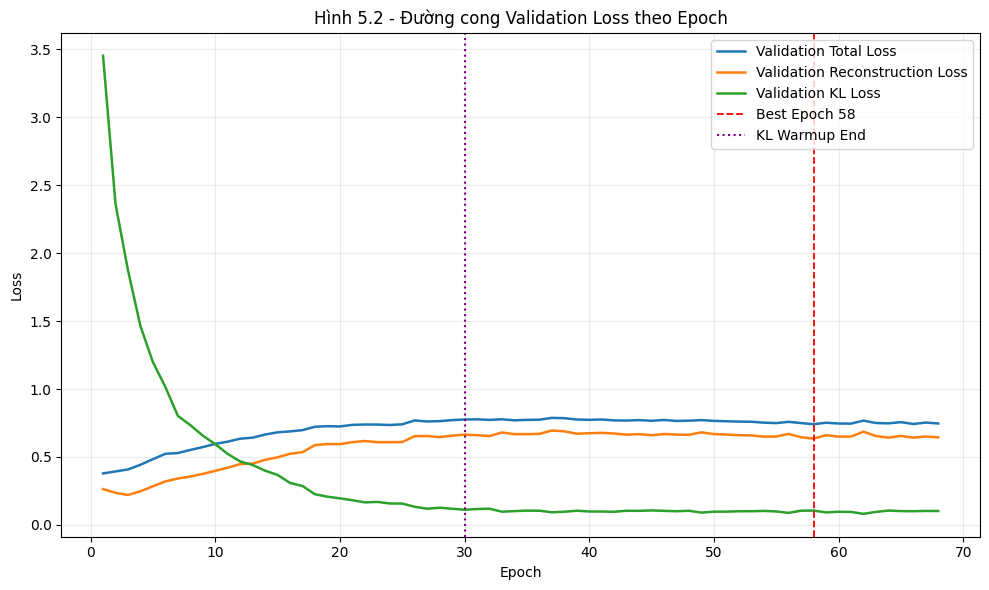

In [9]:
if history_df.empty or not history_df.get("val_loss", pd.Series(dtype=float)).notna().any():
    missing_outputs["Hình 5.2"] = "Thiếu dữ liệu validation loss."
    warn_vi("Không đủ dữ liệu để vẽ Hình 5.2 - Đường cong Validation Loss.")
else:
    plt.figure()
    plot_available_series(history_df, {
        "val_loss": "Validation Total Loss",
        "val_recon_loss": "Validation Reconstruction Loss",
        "val_kl_loss": "Validation KL Loss",
    })
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", linewidth=1.3, label=f"Best Epoch {best_epoch}")
    if warmup_epoch is not None:
        plt.axvline(warmup_epoch, color="purple", linestyle=":", linewidth=1.5, label="KL Warmup End")
    plt.title("Hình 5.2 - Đường cong Validation Loss theo Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    save_figure(FIGURE_DIR / "figure_5_2_validation_loss_curve.png")


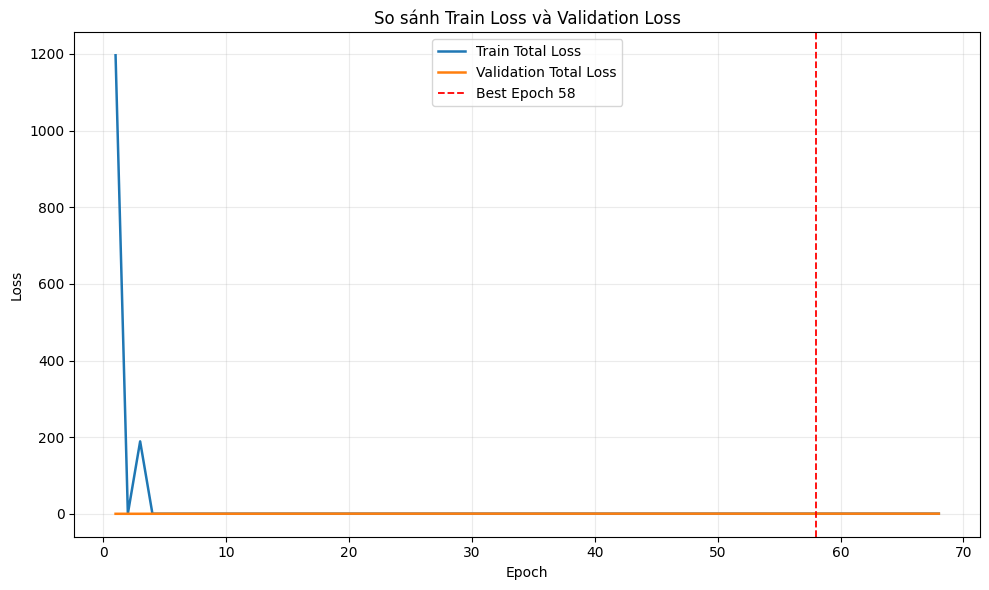

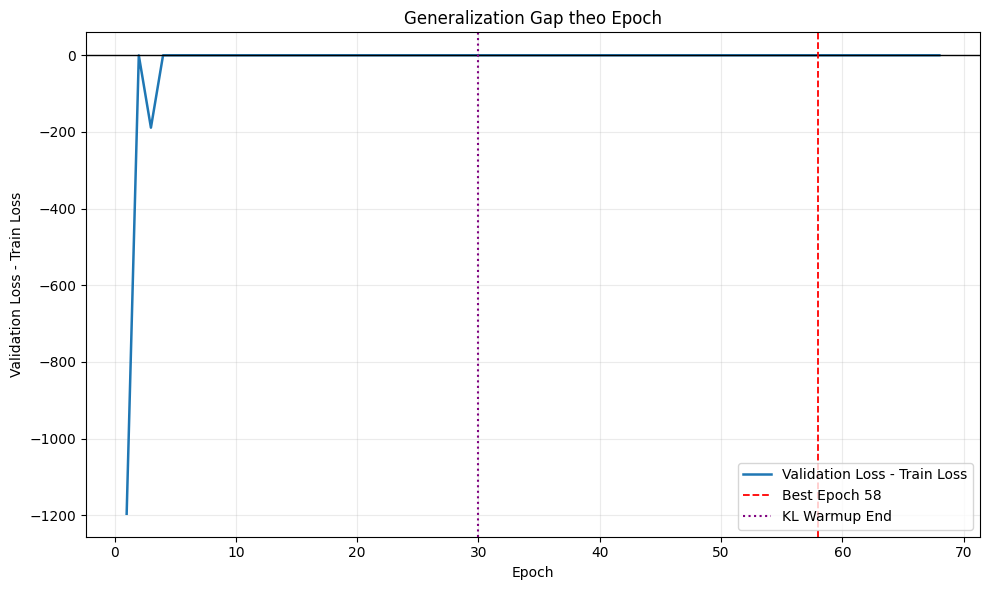

In [10]:
has_train_val = (
    not history_df.empty
    and history_df.get("train_loss", pd.Series(dtype=float)).notna().any()
    and history_df.get("val_loss", pd.Series(dtype=float)).notna().any()
)

if not has_train_val:
    missing_outputs["Hình 5.3"] = "Thiếu train_loss hoặc val_loss."
    warn_vi("Không đủ dữ liệu để vẽ hình so sánh Train Loss và Validation Loss.")
else:
    comparison_df = history_df[["epoch", "train_loss", "val_loss"]].copy()
    comparison_df["generalization_gap"] = comparison_df["val_loss"] - comparison_df["train_loss"]

    plt.figure()
    plt.plot(comparison_df["epoch"], comparison_df["train_loss"], label="Train Total Loss", linewidth=1.8)
    plt.plot(comparison_df["epoch"], comparison_df["val_loss"], label="Validation Total Loss", linewidth=1.8)
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", linewidth=1.3, label=f"Best Epoch {best_epoch}")
    plt.title("So sánh Train Loss và Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    save_figure(FIGURE_DIR / "figure_5_3_train_vs_validation_loss.png")

    plt.figure()
    plt.plot(comparison_df["epoch"], comparison_df["generalization_gap"], label="Validation Loss - Train Loss", linewidth=1.8)
    plt.axhline(0, color="black", linestyle="-", linewidth=1.0)
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", linewidth=1.3, label=f"Best Epoch {best_epoch}")
    if warmup_epoch is not None:
        plt.axvline(warmup_epoch, color="purple", linestyle=":", linewidth=1.5, label="KL Warmup End")
    plt.title("Generalization Gap theo Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss - Train Loss")
    plt.legend()
    save_figure(FIGURE_DIR / "figure_5_4_generalization_gap.png")


In [11]:
METRIC_CANDIDATES = {
    "Accuracy": ["accuracy", "acc"],
    "Precision": ["precision"],
    "Recall": ["recall", "true_positive_rate", "tpr"],
    "F1-score": ["f1_score", "f1", "f1-score"],
    "ROC-AUC": ["roc_auc", "roc-auc", "auc"],
    "False Positive Rate": ["false_positive_rate", "fpr"],
}


def get_metric(metrics_json, candidates):
    # Lấy metric từ cả root hoặc trường metrics lồng nhau.
    if metrics_json is None:
        return np.nan
    nested_metrics = metrics_json.get("metrics", {}) if isinstance(metrics_json, dict) else {}
    value = first_existing(nested_metrics, candidates)
    if value is None:
        value = first_existing(metrics_json, candidates)
    return to_number(value)


if evaluation_metrics is None:
    missing_outputs["Bảng 5.7"] = "Thiếu evaluation_metrics.json."
    missing_outputs["Hình 5.7"] = "Thiếu evaluation_metrics.json."
else:
    rows = []
    metric_values = {}
    for display_name, candidates in METRIC_CANDIDATES.items():
        value = get_metric(evaluation_metrics, candidates)
        if not np.isnan(value):
            metric_values[display_name] = value
            rows.append({
                "Metric": display_name,
                "Value": fmt_value(value),
                "Value (%)": f"{value * 100:.2f}%",
            })

    threshold_value = to_number(evaluation_metrics.get("threshold")) if isinstance(evaluation_metrics, dict) else np.nan
    if not np.isnan(threshold_value):
        rows.append({
            "Metric": "Threshold",
            "Value": fmt_value(threshold_value),
            "Value (%)": "N/A",
        })

    if rows:
        table_5_7 = pd.DataFrame(rows)
        save_table(
            table_5_7,
            TABLE_DIR / "table_5_7_binary_detection_metrics.csv",
            TABLE_DIR / "table_5_7_binary_detection_metrics.md",
        )
        display(table_5_7)
    else:
        missing_outputs["Bảng 5.7"] = "evaluation_metrics.json không có metric phù hợp."
        warn_vi("Không tìm thấy metric phù hợp trong evaluation_metrics.json.")


,Metric,Value,Value (%)
0,Accuracy,0.892018,89.20%
1,Precision,0.865398,86.54%
2,Recall,0.577806,57.78%
3,F1-score,0.692947,69.29%
4,ROC-AUC,0.783550,78.35%
5,False Positive Rate,0.024016,2.40%
6,Threshold,6.031263,N/A


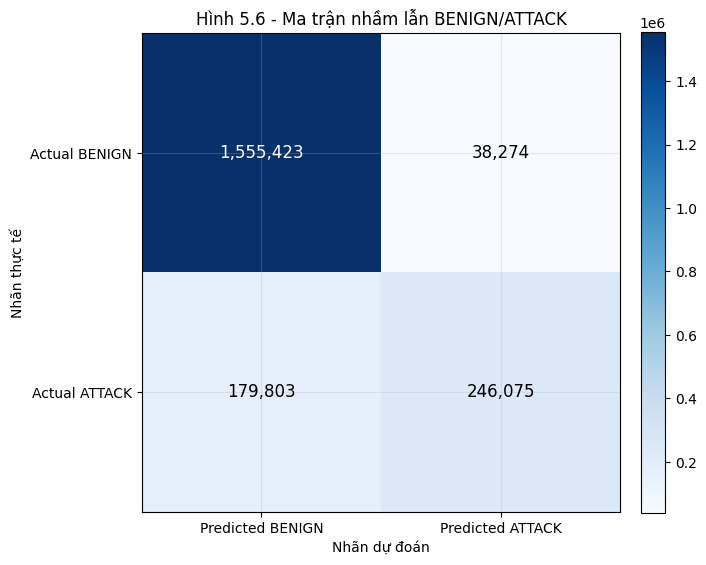

In [12]:
def extract_confusion_matrix(data):
    # Chuyển nhiều dạng confusion matrix về [[TN, FP], [FN, TP]].
    if data is None:
        return None

    source = data.get("confusion_matrix", data) if isinstance(data, dict) else data

    if isinstance(source, dict):
        lower = {str(key).lower(): value for key, value in source.items()}
        if all(key in lower for key in ["tn", "fp", "fn", "tp"]):
            return np.array([
                [int(lower["tn"]), int(lower["fp"])],
                [int(lower["fn"]), int(lower["tp"])],
            ])

    if isinstance(source, list):
        arr = np.array(source)
        if arr.shape == (2, 2):
            return arr.astype(int)
        if arr.size == 4:
            tn, fp, fn, tp = arr.flatten()
            return np.array([[int(tn), int(fp)], [int(fn), int(tp)]])

    return None


cm = extract_confusion_matrix(confusion_matrix_data)
if cm is None:
    missing_outputs["Hình 5.6"] = "Thiếu confusion_matrix.json hoặc định dạng không hỗ trợ."
    warn_vi("Không đủ dữ liệu để vẽ Hình 5.6 - Ma trận nhầm lẫn.")
else:
    plt.figure(figsize=(6.8, 5.8))
    im = plt.imshow(cm, cmap="Blues")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    labels = ["BENIGN", "ATTACK"]
    plt.xticks([0, 1], [f"Predicted {label}" for label in labels])
    plt.yticks([0, 1], [f"Actual {label}" for label in labels])

    # Ghi số lượng từng ô để người đọc thấy trực tiếp TN/FP/FN/TP.
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            plt.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color=color, fontsize=12)

    plt.title("Hình 5.6 - Ma trận nhầm lẫn BENIGN/ATTACK")
    plt.xlabel("Nhãn dự đoán")
    plt.ylabel("Nhãn thực tế")
    save_figure(FIGURE_DIR / "figure_5_6_confusion_matrix.png")


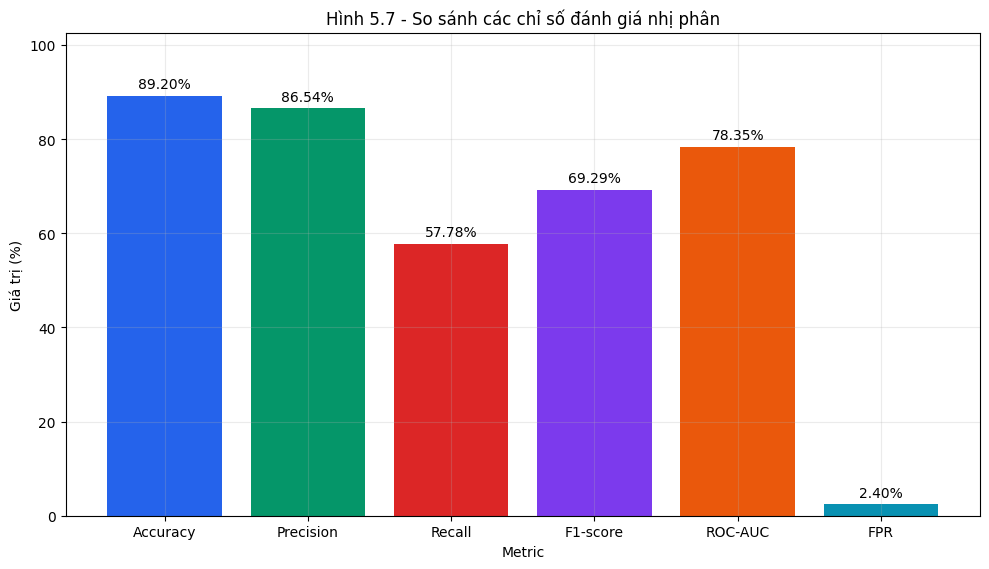

In [13]:
if evaluation_metrics is None:
    missing_outputs["Hình 5.7"] = "Thiếu evaluation_metrics.json."
elif "metric_values" not in globals() or not metric_values:
    missing_outputs["Hình 5.7"] = "evaluation_metrics.json không có metric phù hợp."
else:
    ordered_metrics = [
        ("Accuracy", "Accuracy"),
        ("Precision", "Precision"),
        ("Recall", "Recall"),
        ("F1-score", "F1-score"),
        ("ROC-AUC", "ROC-AUC"),
        ("False Positive Rate", "FPR"),
    ]
    labels = []
    values = []
    for source_name, label in ordered_metrics:
        if source_name in metric_values:
            labels.append(label)
            values.append(metric_values[source_name] * 100)

    if not values:
        missing_outputs["Hình 5.7"] = "Không có Accuracy/Precision/Recall/F1/ROC-AUC/FPR để vẽ."
        warn_vi("Không đủ metric để vẽ Hình 5.7.")
    else:
        plt.figure(figsize=(10, 5.8))
        bars = plt.bar(labels, values, color=["#2563eb", "#059669", "#dc2626", "#7c3aed", "#ea580c", "#0891b2"])
        plt.ylim(0, max(100, max(values) * 1.15))
        plt.title("Hình 5.7 - So sánh các chỉ số đánh giá nhị phân")
        plt.xlabel("Metric")
        plt.ylabel("Giá trị (%)")

        # Ghi giá trị phần trăm trên đầu cột để bảng/hình dễ trích dẫn trong báo cáo.
        for bar, value in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.0,
                f"{value:.2f}%",
                ha="center",
                va="bottom",
                fontsize=10,
            )
        save_figure(FIGURE_DIR / "figure_5_7_metrics_comparison.png")


## Ghi chú về đánh giá theo từng loại tấn công

Hiện tại artifact nhị phân chỉ đủ để đánh giá BENIGN/ATTACK tổng thể. Muốn tạo Bảng 5.7 theo từng loại tấn công như DDoS, PortScan, Brute-force, Web Attack, Infiltration thì cần lưu thêm nhãn gốc CICIDS2017 của test set và tính recall theo từng label. Notebook này không tự tạo số liệu theo từng loại tấn công nếu chưa có dữ liệu thật.

In [14]:
expected_outputs = [
    TABLE_DIR / "table_5_3_train_loss.csv",
    TABLE_DIR / "table_5_3_train_loss.md",
    TABLE_DIR / "table_5_4_validation_loss.csv",
    TABLE_DIR / "table_5_4_validation_loss.md",
    TABLE_DIR / "table_5_7_binary_detection_metrics.csv",
    TABLE_DIR / "table_5_7_binary_detection_metrics.md",
    FIGURE_DIR / "figure_5_1_train_loss_curve.png",
    FIGURE_DIR / "figure_5_2_validation_loss_curve.png",
    FIGURE_DIR / "figure_5_3_train_vs_validation_loss.png",
    FIGURE_DIR / "figure_5_4_generalization_gap.png",
    FIGURE_DIR / "figure_5_6_confusion_matrix.png",
    FIGURE_DIR / "figure_5_7_metrics_comparison.png",
]

print("Các file đã tạo:")
for path in expected_outputs:
    if path.exists():
        print(f"- {path.relative_to(PROJECT_ROOT)}")

not_created = [path for path in expected_outputs if not path.exists()]
if not_created:
    print("\nCác file chưa tạo được:")
    for path in not_created:
        reason = "Thiếu dữ liệu đầu vào tương ứng."
        for key, value in missing_outputs.items():
            if key in path.name:
                reason = value
                break
        print(f"- {path.relative_to(PROJECT_ROOT)}: {reason}")
else:
    print("\nTất cả output yêu cầu đã được tạo thành công.")


Các file đã tạo:
- reports\tables\table_5_3_train_loss.csv
- reports\tables\table_5_3_train_loss.md
- reports\tables\table_5_4_validation_loss.csv
- reports\tables\table_5_4_validation_loss.md
- reports\tables\table_5_7_binary_detection_metrics.csv
- reports\tables\table_5_7_binary_detection_metrics.md
- reports\figures\figure_5_1_train_loss_curve.png
- reports\figures\figure_5_2_validation_loss_curve.png
- reports\figures\figure_5_3_train_vs_validation_loss.png
- reports\figures\figure_5_4_generalization_gap.png
- reports\figures\figure_5_6_confusion_matrix.png
- reports\figures\figure_5_7_metrics_comparison.png

Tất cả output yêu cầu đã được tạo thành công.
